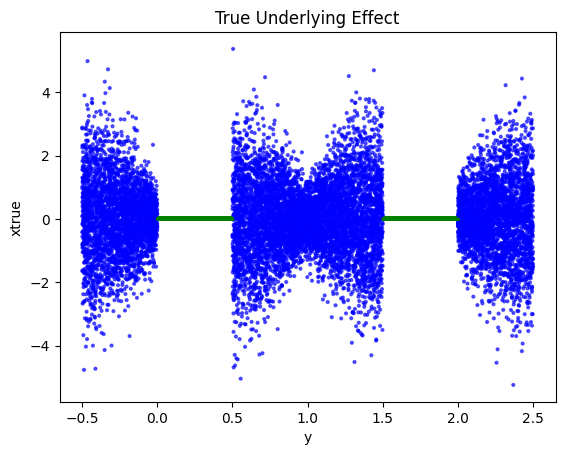

[CASH] Epoch 10/20 | Loss: 231.1858
[CASH] Epoch 20/20 | Loss: 230.5007
Posterior means (first 10): tensor([ 9.2672e-04, -1.7663e-04,  9.4390e-02, -7.8959e-04,  2.1128e-01,
         1.5109e-03, -8.1207e-01, -4.4333e-03, -1.4812e-02,  2.3945e-01])
Posterior sds (first 10): tensor([0.0595, 0.0690, 0.4482, 0.0646, 0.6367, 0.0579, 1.3112, 0.0923, 0.1694,
        0.7358])
Fitted mixture weights shape: torch.Size([20000, 10])


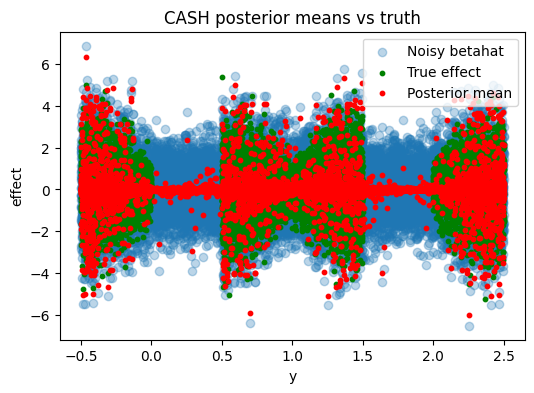

In [ ]:
import math
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from cebmf_torch.cebnm.cash_solver import cash_posterior_means   # adjust path if solver file has another name

# Reproducibility
torch.manual_seed(1)

# Generate data in PyTorch
n_samples = 20_000
y = torch.empty(n_samples).uniform_(-0.5, 2.5)        # U(-0.5, 2.5)
X = y.view(-1, 1)

# masks for zero vs nonzero regions
mask_zero = ((y > 0) & (y < 0.5)) | ((y > 1.5) & (y < 2.0))

# std depends on y
noise_std = 0.5 + torch.abs(torch.sin(math.pi * y))

# xtrue: 0 in masked regions, Gaussian elsewhere with that std
xtrue = torch.where(mask_zero, torch.zeros_like(y), torch.randn_like(y) * noise_std)

# Observed data
x = xtrue + torch.randn_like(xtrue)   # add N(0,1) noise
s = torch.ones_like(x)                # all ones
Z = torch.ones(n_samples, 1)          # design column of ones

# Plot
colors = torch.where(xtrue == 0, torch.tensor(0), torch.tensor(1))  # 0/1 labels
plt.scatter(y.cpu().numpy(), xtrue.cpu().numpy(),
            c=['green' if c == 0 else 'blue' for c in colors.tolist()],
            s=4, alpha=0.6)
plt.title('True Underlying Effect')
plt.xlabel('y'); plt.ylabel('xtrue')
plt.show()

res = cash_posterior_means(
    X=X,
    betahat=x,
    sebetahat=s      ,
    n_epochs=20,          # keep small for testing
    n_layers=2,
    num_classes=10,
    hidden_dim=32,
    batch_size=128,
    lr=1e-3,
    penalty=1.5
)

# -------------------
# Step 3: Inspect results
# -------------------
print("Posterior means (first 10):", res.post_mean[:10])
print("Posterior sds (first 10):", res.post_sd[:10])
print("Fitted mixture weights shape:", res.pi_np.shape)

# Plot true vs posterior means
plt.figure(figsize=(6,4))
plt.scatter(y, x, alpha=0.3, label="Noisy betahat")
plt.scatter(y, xtrue, c="green", s=10, label="True effect")
plt.scatter(y, res.post_mean, c="red", s=10, label="Posterior mean")
plt.legend()
plt.xlabel("y")
plt.ylabel("effect")
plt.title("CASH posterior means vs truth")
plt.show()


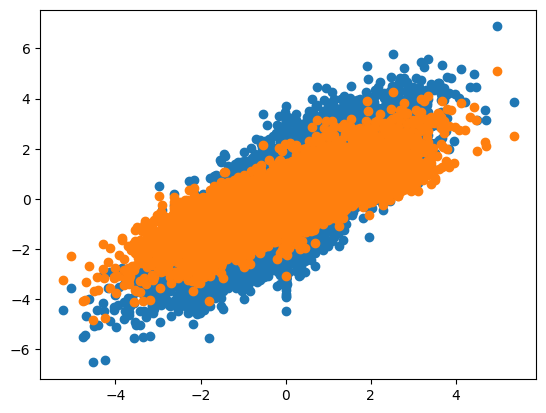

In [ ]:
 
plt.scatter( xtrue, x )
plt.scatter( xtrue, res.post_mean )

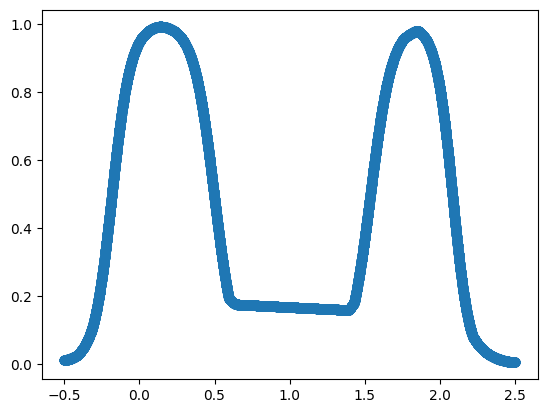

In [ ]:
plt.scatter( y, res.pi_np[:,0] )

In [ ]:
def normal_means_loglik(
    x: torch.Tensor,
    s: torch.Tensor,
    Et: torch.Tensor,
    Et2: torch.Tensor,
    mask: torch.Tensor | None = None,
    reduce: str = "sum",
    eps: float = 1e-8,
) -> torch.Tensor:
    """
    Compute the expected normal-means log-likelihood.

    E_q[ log N(x | theta, s^2) ] with q giving Et, Et2.

    Parameters
    ----------
    x : torch.Tensor
        Observed data (broadcastable with s, Et, Et2).
    s : torch.Tensor
        Standard errors (broadcastable).
    Et : torch.Tensor
        Posterior means (broadcastable).
    Et2 : torch.Tensor
        Posterior second moments (broadcastable).
    mask : torch.Tensor or None, optional
        Optional bool mask; True = include entry.
    reduce : str, optional
        'sum' (default), 'mean', or 'none' (per-element with NaNs for excluded).
    eps : float, optional
        Numerical floor for variance.

    Returns
    -------
    torch.Tensor
        Scalar if reduce in {'sum','mean'}, else elementwise tensor.
    """
    # Ensure common dtype/device via broadcasting
    x, s, Et, Et2 = torch.broadcast_tensors(x, s, Et, Et2)

    # Validity mask: finite & s > 0
    valid = torch.isfinite(x) & torch.isfinite(s) & torch.isfinite(Et) & torch.isfinite(Et2) & (s > 0)
    if mask is not None:
        valid = valid & mask.to(dtype=torch.bool, device=x.device)

    if not valid.any():
        if reduce == "none":
            return torch.full_like(x, float("nan"))
        return x.new_tensor(float("nan"))

    # Stable variance and constant term
    var = (s * s).clamp_min(eps)  # s^2 ≥ eps
    c2pi = x.new_tensor(math.log(2.0 * math.pi))  # stays on same device/dtype

    # E[(x - theta)^2] = Et2 - 2*x*Et + x^2
    quad = Et2 - 2.0 * x * Et + x * x
    ll_el = -0.5 * (c2pi + torch.log(var) + quad / var)

    if reduce == "sum":
        return ll_el[valid].sum()
    elif reduce == "mean":
        return ll_el[valid].mean()
    elif reduce == "none":
        out = torch.full_like(x, float("nan"))
        out[valid] = ll_el[valid]
        return out
    else:
        raise ValueError("reduce must be 'sum', 'mean', or 'none'")


In [ ]:
 
betahat=x 
sebetahat=s
normal_means_loglik(x= betahat, s=sebetahat, Et=res .post_mean, Et2=res .post_mean2)

tensor(-28503.7188)

In [ ]:
res.loss

33843.74038696289

In [ ]:
from cebmf_torch.ebnm.ash import ash

resa= ash(betahat, sebetahat    )

In [ ]:

normal_means_loglik(x= betahat, s=sebetahat, Et=resa.post_mean, Et2=resa.post_mean2)

tensor(-28639.0195)

In [ ]:
resa.log_lik

-34849.44921875

: 